**ANALISIS Y LIMPIEZA DE DATOS**

In [17]:
#bibliotecas
import pandas as pd
import numpy as np

In [18]:
#Leer el dataset
df = pd.read_csv('data/netflix_customer_churn.csv')

In [19]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [21]:
#Eliminar id que no es relevate

df = df.drop('customer_id', axis=1)

In [22]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def procesar_var_cat(df, column):
    encoder = OneHotEncoder(sparse_output=False)

    encoded = encoder.fit_transform(df[[column]])

    df_encoded = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out([column]),
        index=df.index
    )

    df = df.drop(column, axis=1)
    df = pd.concat([df, df_encoded], axis=1)

    return df

In [23]:
cat_cols = df.select_dtypes(include='object').columns

In [24]:
for col in cat_cols:
    df = procesar_var_cat(df, col)

In [25]:
X = df.drop('churned', axis=1)

In [26]:
y = df['churned']

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

**MODELO**

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [30]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**EVALUACIÓN**

In [31]:
model.score(X_train, y_train)

0.899

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       490
           1       0.88      0.88      0.88       510

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



array([[428,  62],
       [ 60, 450]])

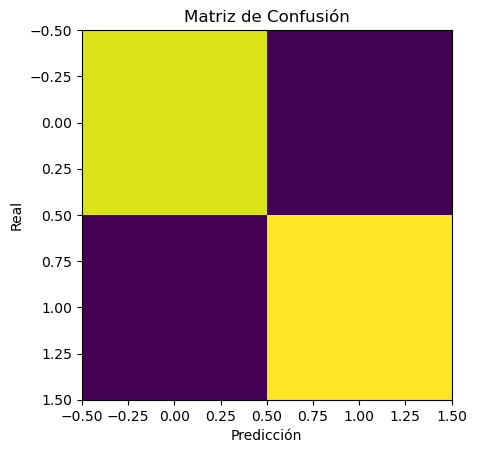

In [34]:
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()